**Applied Machine Learning Lab-(MCSE630P)**

**Assignment 1 - Multiple Linear Regression Model**

**Name:** Shrihariharan S [24MCS1058]

Multiple Linear Regression:

* Taken the dataset from Kaggle for Prediction of Student Performance (dependent variable) based on the other features like hours studied, previous scores,extracurricular activities,etc.,(Dependent variables).

* Done the some preprocessing of data, split the data into training set and testing set.

* Trained the model using Training set data using the Linear regression function and used predict function to predict the values for X_test data set.

* Then  ploted the Predicted_Y_value and actual Y_test value in the scatterplot and visualized the linear regression model.

* Found the r squared value for this model to find the performance metrics.






In [1]:
! pip install -q kaggle

In [2]:
from google.colab import files

files.upload() # uploading Json file downloaded from Kaggle

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shrihariharanshankar","key":"837f3e44a5a2f4e1f9afeba5d0ddaa2b"}'}

In [3]:
! mkdir ~/.kaggle

In [4]:
! cp kaggle.json ~/.kaggle/

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

In [6]:
! kaggle datasets list #fetch the list of Datasets from Kaggle

401 - Unauthorized - Unauthenticated


In [7]:
! kaggle datasets download -d kaggle nikhil7280/student-performance-multiple-linear-regression # downloading the Dataset zip file from Kaggle

Dataset URL: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
License(s): other
  0% 0.00/48.5k [00:00<?, ?B/s]
100% 48.5k/48.5k [00:00<00:00, 44.6MB/s]


In [8]:
import zipfile
f=zipfile.ZipFile('/content/student-performance-multiple-linear-regression.zip','r') #unzipping the downloaded file
f.extractall('/content')
f.close()


In [9]:
#importing the required library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [10]:
student_performance = pd.DataFrame(pd.read_csv("/content/Student_Performance.csv")) #reading csv data and assigning it to student_performance variable
student_performance.head()# first 5 rows of the dataset

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [11]:
type(student_performance) # display the dataset type


pandas.core.frame.DataFrame

In [12]:
student_performance.shape #displays the rows and column in the dataset

(10000, 6)

In [13]:
student_performance.info() #display the information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [14]:
student_performance.describe() # describes the mean, median and other values

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [15]:
student_performance.isna().sum() #checking for null vales

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [16]:
student_performance.tail() #displays last 5 data elements

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [17]:
student_performance.shape

(10000, 6)

In [18]:
print(student_performance.columns)

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [19]:
student_performance.tail()# last 5 rows of the dataset


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [20]:
# converting the categorical value 'Extracurricular Activities' into the numerical value (0 and 1)- categorical data into numerical data
student_performance['Extracurricular Activities'] = student_performance['Extracurricular Activities'].astype('category')
student_performance['Extracurricular Activities'] = student_performance['Extracurricular Activities'].cat.codes
student_performance.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [21]:
student_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int8   
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), int8(1)
memory usage: 400.5 KB


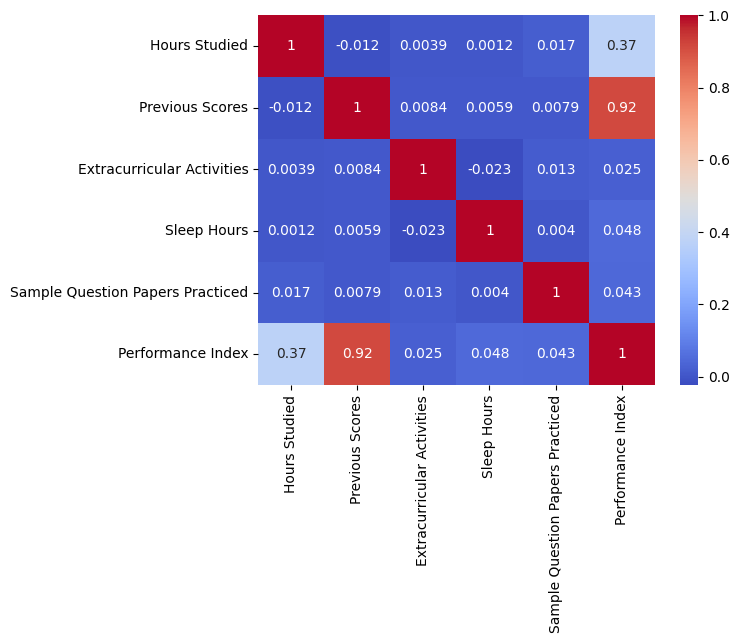

In [22]:
sns.heatmap(student_performance.corr(),annot=True,cmap='coolwarm') #heatmap is used for co-relation of data, here cmap attribute changes the colour palatte of the heatmap and annot will display the values
plt.show()

In [23]:
#defining X (independent variable) and Y (dependent variable)i.e., Performance Index in Y and remaining independent variables in X
X =student_performance.drop(columns='Performance Index').values
Y = student_performance['Performance Index'].values

print(X)


[[ 7 99  1  9  1]
 [ 4 82  0  4  2]
 [ 8 51  1  7  2]
 ...
 [ 6 83  1  8  5]
 [ 9 97  1  7  0]
 [ 7 74  0  8  1]]


In [24]:
print(Y)

[91. 65. 45. ... 74. 95. 64.]


In [25]:
#Split the data set into training set and testing set using library Scikit function train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=0) #30% of data is taken as test data so the test_size=0.3

In [26]:
#Train the model with the training set using Linear Regression Function
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)



LinearRegression()

In [27]:
y_pred_test =lr.predict(x_test)
print(y_pred_test)

[50.46443613 53.10077726 78.27207629 ... 61.92684246 39.15895897
 89.59303935]


In [28]:
lr.predict([[7,99,1,9,1]]) #expected Y value for this values of x 91.0 and below is the predicted output

array([91.88368083])

In [29]:
#Evaluate the model by r-squared score
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_test)

0.9888065859708454

Text(0.5, 1.0, 'Actual vs Predicted (test data)')

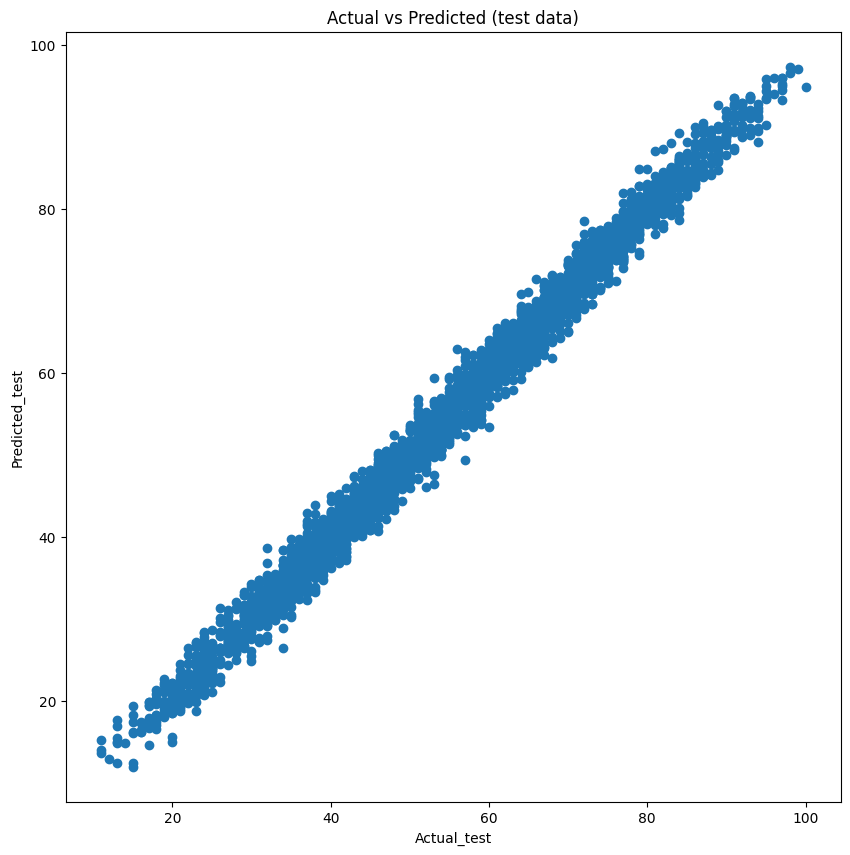

In [30]:
#visualize the  model using scatterplot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(y_test,y_pred_test)
plt.xlabel('Actual_test')
plt.ylabel('Predicted_test')
plt.title('Actual vs Predicted (test data)')


In [31]:
pred_y_df_test= pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred_test,'Difference':(y_test-y_pred_test)})
pred_y_df_test #checking the difference between Predicted and actual values


,Actual Value,Predicted Value,Difference
0,53.0,50.464436,2.535564
1,50.0,53.100777,-3.100777
2,80.0,78.272076,1.727924
3,24.0,25.362963,-1.362963
4,64.0,67.432695,-3.432695
...,...,...,...
2995,73.0,69.639832,3.360168
2996,31.0,30.661211,0.338789
2997,62.0,61.926842,0.073158
2998,39.0,39.158959,-0.158959


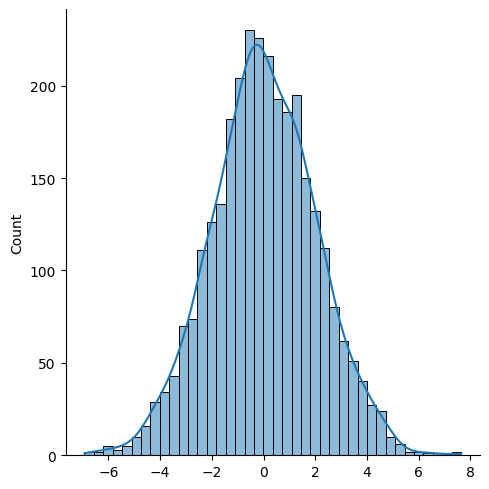

In [32]:
sns.displot((y_test-y_pred_test), kde=True)


In [33]:
#y=mx+c
C=lr.intercept_ #value of C
print(C)

-34.06212023657093


In [34]:
m= lr.coef_ #value of m for 5 input variables
print(m)

[2.84957996 1.01941699 0.62178694 0.47426223 0.18631283]


In [35]:
y_pred_train = lr.predict(x_train) # Predicting the Y values using the X_train data
print(y_pred_train)

[55.57773157 35.87232508 59.25934928 ... 50.66207503 25.57809847
 77.9483268 ]


In [36]:
from sklearn.metrics import r2_score
r2_score(y_train,y_pred_train)

0.988725946864821

Text(0.5, 1.0, 'Actual vs Predicted (training)')

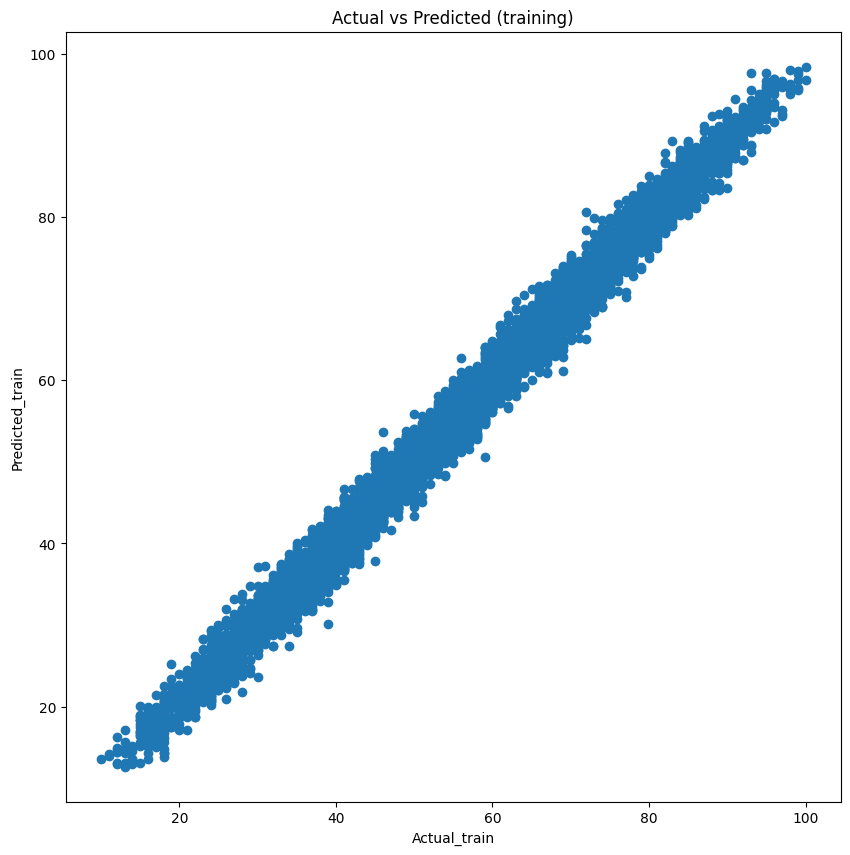

In [37]:
plt.figure(figsize=(10,10))
plt.scatter(y_train,y_pred_train)



plt.xlabel('Actual_train')
plt.ylabel('Predicted_train')
plt.title('Actual vs Predicted (training)')

In [38]:
pred_y_df_train= pd.DataFrame({'Actual Value':y_train,'Predicted Value':y_pred_train,'Difference':(y_train-y_pred_train)})
pred_y_df_train

,Actual Value,Predicted Value,Difference
0,55.0,55.577732,-0.577732
1,34.0,35.872325,-1.872325
2,60.0,59.259349,0.740651
3,48.0,48.641909,-0.641909
4,53.0,49.957850,3.042150
...,...,...,...
6995,51.0,48.506241,2.493759
6996,68.0,67.936121,0.063879
6997,54.0,50.662075,3.337925
6998,27.0,25.578098,1.421902


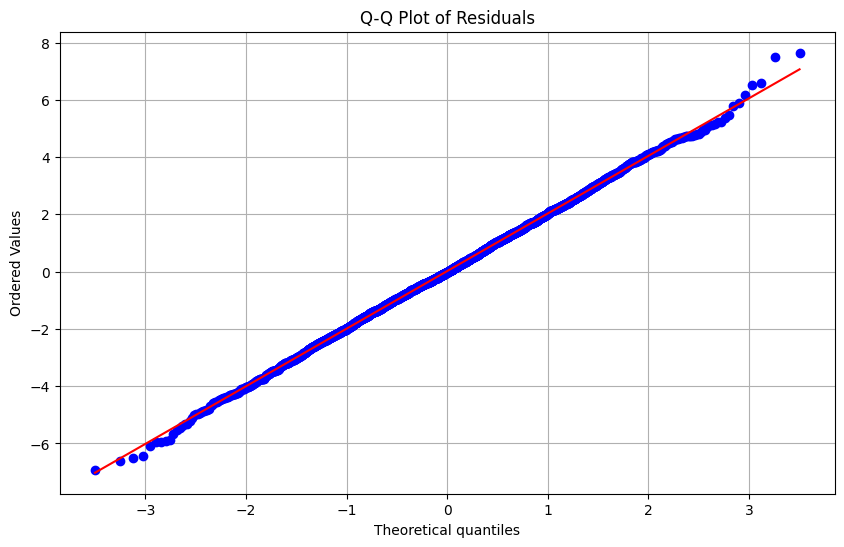

In [39]:
import scipy.stats as sts
plt.figure(figsize=(10, 6))
sts.probplot((y_test-y_pred_test), dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

In [40]:
mse_test = mean_squared_error(y_test,y_pred_test) # checking for the Mean squared error value
print(mse_test)

4.03951919169885


In [41]:
mse_train = mean_squared_error(y_train,y_pred_train)
print(mse_train)

4.200718511407367


In [42]:
print(
    f"coefficient of determination: {lr.score(x_test, y_test)}\n",
    f"mean_absolute_error {mean_absolute_error(lr.predict(x_test), y_test)}"
)

coefficient of determination: 0.9888065859708454
 mean_absolute_error 1.5950954457162965


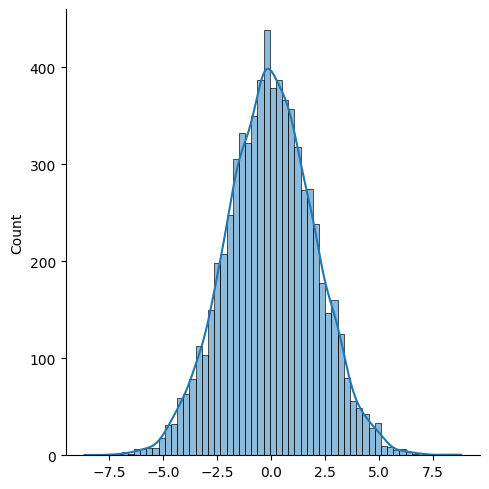

In [43]:
sns.displot((y_train-y_pred_train), kde=True)


LinregressResult(slope=1.0138367015830554, intercept=-15.181799427126393, rvalue=0.9151891412264473, pvalue=0.0, stderr=0.0044651098716746085, intercept_stderr=0.31960519441589297)


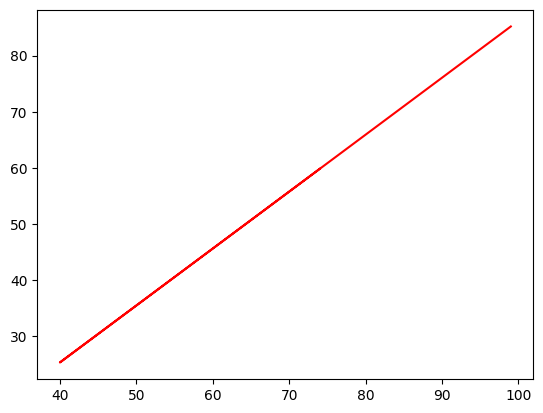

In [44]:
#sample-trail Previous Scores vs Performance Index
sample_x= student_performance['Previous Scores']
sample_y= student_performance['Performance Index']
from scipy import stats

#plt.boxplot(sample_y)
#plt.boxplot(sample_x)
linemodel_1=stats.linregress(sample_x,sample_y)
print(linemodel_1)

best_fit_line = 1.0138367015830554*sample_x+(-15.181799427126393)
plt.plot(sample_x,best_fit_line,color='red')
plt.show()

In [45]:
student_performance.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [46]:
# training the model using the data that are highly corelated in Heat Map
X_new = student_performance.iloc[:, 0:2]
Y_new=student_performance['Performance Index'].values
pd.DataFrame(X_new)

,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75
...,...,...
9995,1,49
9996,7,64
9997,6,83
9998,9,97


In [47]:
x_train,x_test,y_train,y_test = train_test_split(X_new,Y_new,test_size=0.3,random_state=0)

In [48]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [49]:
y_pred_test =lr.predict(x_test)
print(y_pred_test)

[49.89520692 54.17012356 79.07183754 ... 63.36641004 39.48504218
 88.25495267]


In [50]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred_test)

0.9855989148980643

Text(0.5, 1.0, 'Actual vs Predicted (training)')

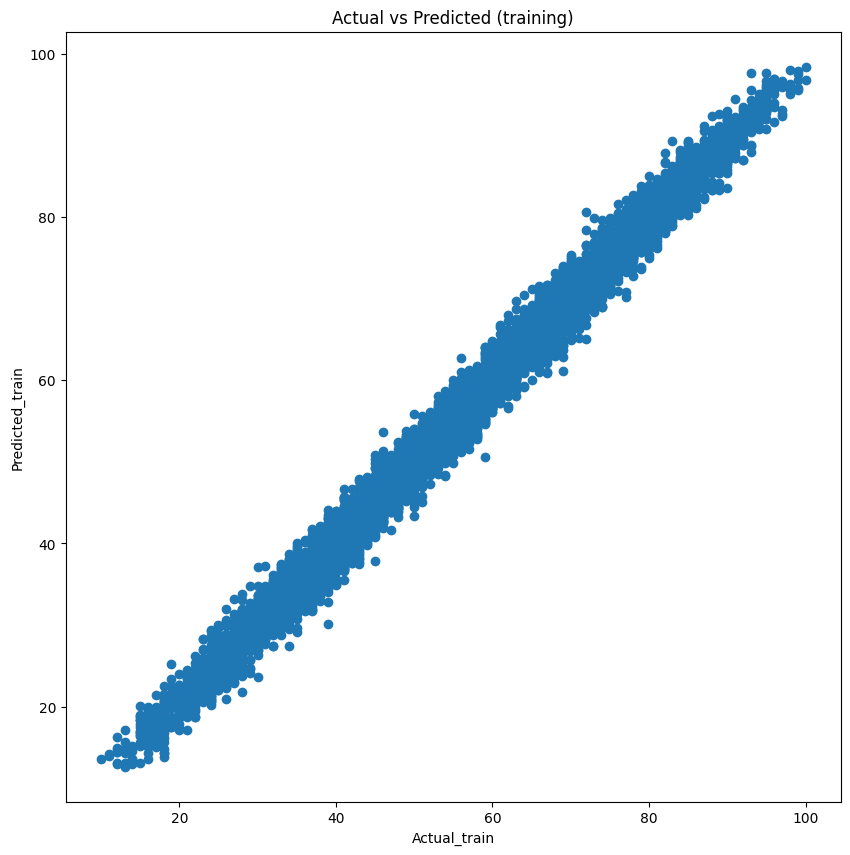

In [51]:
plt.figure(figsize=(10,10))
plt.scatter(y_train,y_pred_train)



plt.xlabel('Actual_train')
plt.ylabel('Predicted_train')
plt.title('Actual vs Predicted (training)')

In [52]:
# Conclusion

#In conclusion, the linear regression model has provided valuable insights into the relationship between the predictor variables and the response variable.
#The model has provided the r-squared value of 0.9888065859708454.
# The model could predict the student performance based on the provided features/parameters.